In [6]:
import matplotlib.pyplot as plt
import joblib as jlb
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from pyclustering.utils import timedcall
from data_processing import D

In [7]:
#Class Clarans
import numpy as np
class CLARANS:
    def __init__(self,data,n_clusters,num_local,max_neighbors):
        self.data=data
        self.n_clusters=n_clusters
        self.num_local=num_local
        self.max_neighbors=max_neighbors
        self.labels=None
        self.medoids=None
        self.sihouette_score_=None

    def _euclid_dist(self,X,medoids):
        return  np.linalg.norm(X[:, np.newaxis] -medoids,axis=2)
    def _compute_total_cost(self,X,medoids):
        distances=self._euclid_dist(X,medoids)
        return np.sum(np.min(distances,axis=1))
    def fit(self):
        X=self.data.values
        best_cost=float('inf')

        for _ in range(self.num_local):
            medoids_idx=np.random.choice(len(X),self.n_clusters,replace=False)
            medoids=X[medoids_idx]

            current_cost=self._compute_total_cost(X,medoids)
            neighbor=0
            while neighbor<self.max_neighbors:
                medoids_random_pos=np.random.randint(self.n_clusters)
                candidate_idx = np.random.randint(len(X))
                while candidate_idx in medoids_idx:
                    candidate_idx=np.random.randint(len(X))

                new_medoids_idx = medoids_idx.copy()
                new_medoids_idx[medoids_random_pos] = candidate_idx
                new_medoids = X[new_medoids_idx]

                new_cost=self._compute_total_cost(X,new_medoids)
                if current_cost>new_cost:
                    medoids=new_medoids
                    medoids_idx = new_medoids_idx
                    current_cost=new_cost
                    neighbor=0
                else:
                    neighbor+=1
            if current_cost<best_cost:
                best_cost=current_cost
                self.medoids=medoids
        distances=self._euclid_dist(X,self.medoids)
        self.labels=np.argmin(distances,axis=1)
        self.Inertia_=best_cost
    def get_medoids(self):
        return self.medoids
    def get_labels(self):
        return self.labels
    def get_Inertia(self):
        return self.Inertia_


#CLARANS fast build
def clarans_fast_build(data,n_clusters,num_local,max_neighbors,first_column,second_column):

    model=CLARANS(data,n_clusters,num_local,max_neighbors)
    model.fit()

    medoids=model.get_medoids()
    labels=model.get_labels()
    data['cluster'] = labels
    
    model.sihouette_score_= silhouette_score(data.drop(columns=['cluster']), labels)
    print(f'Silhouette Score: {model.sihouette_score_:.4f}')

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=data[first_column],
            y=data[second_column],
            hue=data['cluster'], palette="Set2")

    for i, medoid in enumerate(medoids):
        plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
    plt.scatter(medoids[:, 0],
        medoids[:, 1],
        marker='s',
        s=100,color='red')
    plt.xlabel(first_column)
    plt.ylabel(second_column)
    plt.title("CLARANS Customer Segmentation")

    plt.show()

def clarans_silhouette_analysis(data, k_range, num_local, max_neighbors,print_scores=False):
    silhouette_scores = []
    for k in k_range:
        model = CLARANS(data, k, num_local, max_neighbors)
        model.fit()
        model.sihouette_score_=silhouette_score(data,model.get_labels())
        silhouette_scores.append(model.sihouette_score_)
        if print_scores:
            print(f'k={k}, Silhouette Score: {model.sihouette_score_:.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, silhouette_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis for CLARANS')
    plt.show()

def clarans_davies_bouldin_analysis(data, k_range, num_local, max_neighbors,print_scores=False):
    db_scores = []
    for k in k_range:
        model = CLARANS(data, k, num_local, max_neighbors)
        model.fit()
        db_score = davies_bouldin_score(data, model.get_labels())
        db_scores.append(db_score)
        if print_scores:
            print(f'k={k}, Davies-Bouldin Score: {db_score:.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, db_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Davies-Bouldin Score')
    plt.title('Davies-Bouldin Analysis for CLARANS')
    plt.show()
    
def clarans_Inertia_analysis(data, k_range, num_local, max_neighbors,print_scores=False):
    inertia_scores = []
    k_values=k_range
    for k in k_range:
        model = CLARANS(data, k, num_local, max_neighbors)
        model.fit()
        inertia = model.get_Inertia()
        inertia_scores.append(inertia)
        if print_scores:
            print(f'k={k}, Inertia: {inertia:.4f}')
    kneedle=KneeLocator(k_values,inertia_scores,curve='convex',direction='decreasing')
    k_optimal=kneedle.knee
    
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia_scores, marker='o')
    plt.axvline(x=k_optimal, linestyle='--')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Inertia Analysis for CLARANS')
    plt.show()

In [8]:
features=['Income','Age','Total_Spend']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 3)
     Income       Age  Total_Spend
0  0.316484  1.015715     1.204332


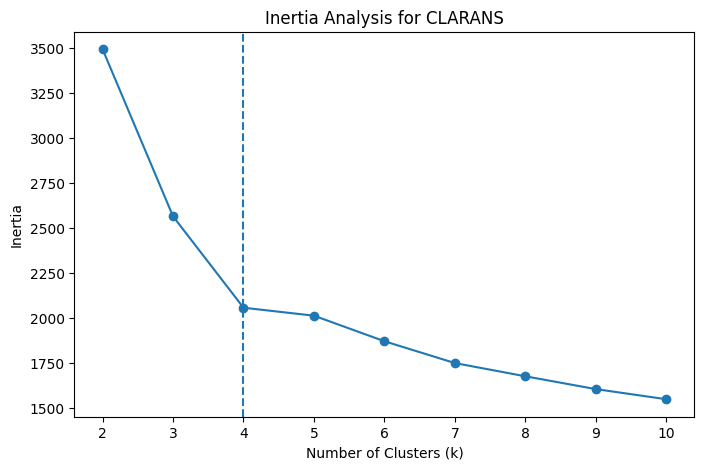

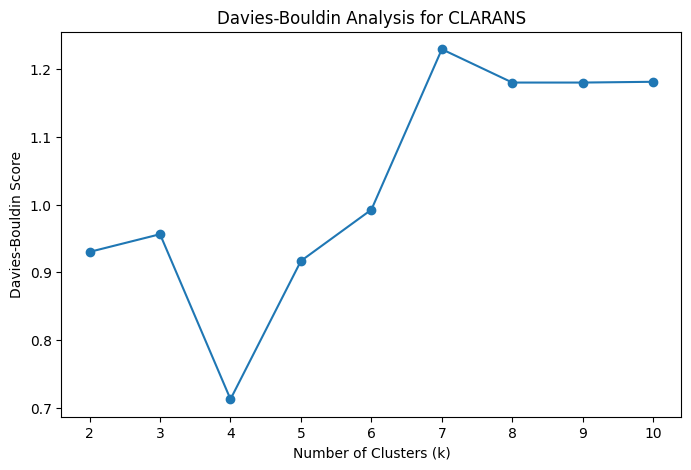

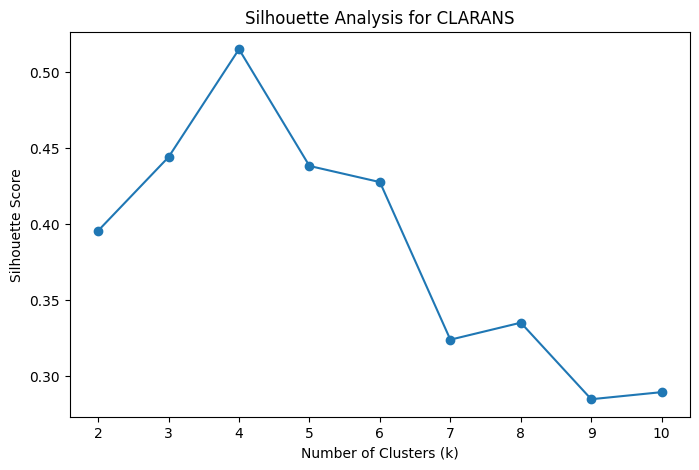

In [ ]:
#Chạy để chọn k tốt nhất
k=[2,3,4,5,6,7,8,9,10]
n_local=5
max_nei=20
clarans_Inertia_analysis(data,k,num_local=n_local,max_neighbors=max_nei)
clarans_davies_bouldin_analysis(data,k,num_local=n_local,max_neighbors=max_nei)
clarans_silhouette_analysis(data,k,num_local=n_local,max_neighbors=max_nei)

In [ ]:
#Chạy để tune tham số
k=4
local_list=[2,5,10,20]
neighbor_list=[5,10,20,50,100,250]
silhouette_scores=[]
davieboudin_scores=[]
params=[]

for local in local_list:
    for neighbor in neighbor_list:
        model = CLARANS(data, k, local, neighbor)
        model.fit()
        labels=model.get_labels()

        sihouette_score_=silhouette_score(data,labels)
        silhouette_scores.append(sihouette_score_)

        davieboudin_score_=davies_bouldin_score(data,labels)
        davieboudin_scores.append(davieboudin_score_)

        params.append((local,neighbor))

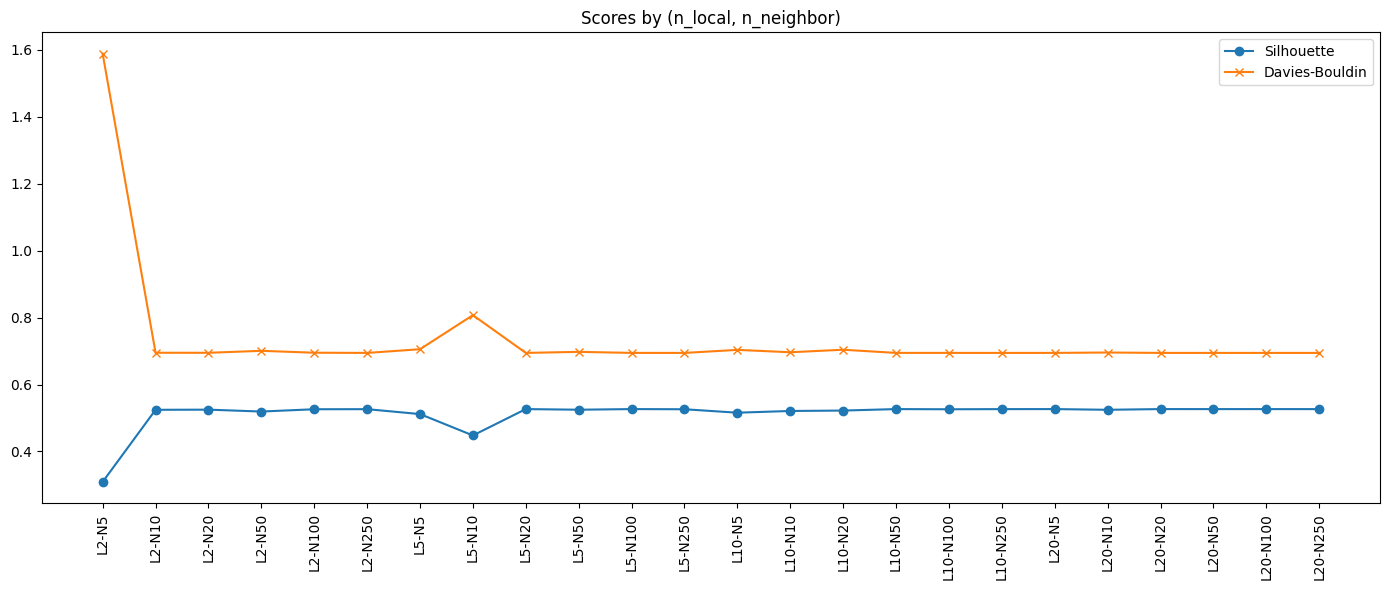

In [ ]:
#hiển thị david vs silhouette
labels_x = [f"L{l}-N{n}" for l, n in params]

plt.figure(figsize=(14,6))

plt.plot(silhouette_scores, marker='o', label='Silhouette')
plt.plot(davieboudin_scores, marker='x', label='Davies-Bouldin')

plt.xticks(range(len(labels_x)), labels_x, rotation=90)

plt.legend()
plt.title("Scores by (n_local, n_neighbor)")
plt.tight_layout()
plt.show()

In [52]:
#xay dung model clarans
k = 4
n_local=5
max_nei=20
Clarans_model = CLARANS(data, k, n_local, max_nei)
(ticks, result) = timedcall(Clarans_model.fit)
print(f"Time taken: {ticks:.4f} seconds")

Time taken: 0.0247 seconds


In [53]:
#lấy cluster và medoids
labels=Clarans_model.get_labels()
medoids = Clarans_model.get_medoids()

print("Labels:", labels)
print("Medoids:", medoids)

Labels: [2 3 0 ... 0 2 2]
Medoids: [[ 0.9616879  -0.77842064  0.54435136  3.        ]
 [-1.190464   -1.20559569 -1.35512561  0.        ]
 [ 0.85574806  1.10114957  0.76031187  1.        ]
 [-0.50224343  0.75940953 -1.02111932  2.        ]]


In [54]:
#gắn nhãn cluster đã có vào df
data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

     Income       Age  Total_Spend  cluster
0  0.316484  1.015715     1.204332        2
1 -0.256135  1.272020    -1.563480        3
2  0.970719  0.332234     0.703879        0
3 -1.212506 -1.291031    -1.115376        1
4  0.324010 -1.034726     0.289010        0

Kích thước clusters: Counter({np.int64(0): 756, np.int64(1): 530, np.int64(2): 489, np.int64(3): 454})

2 clusters lớn nhất: [(np.int64(0), 756), (np.int64(1), 530)]


In [55]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [56]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

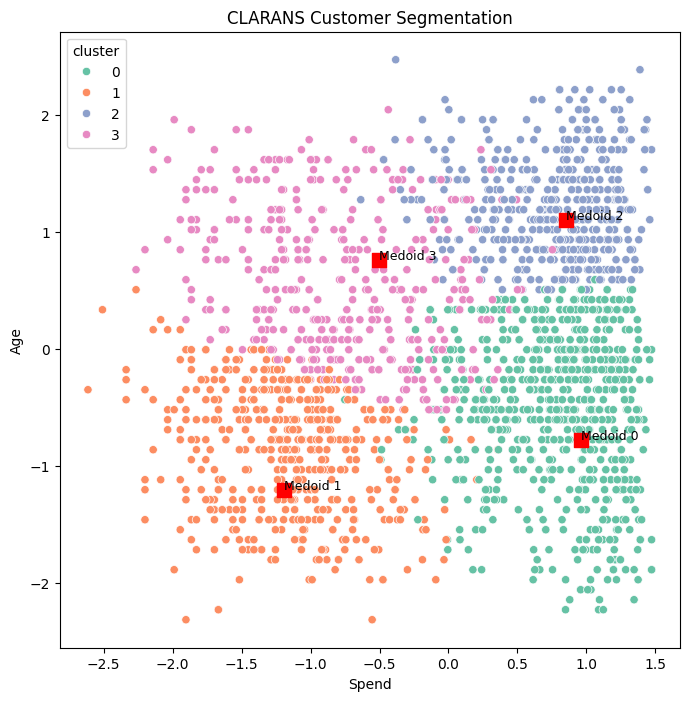

In [57]:
#hien thi model

plt.figure(figsize=(8,8))

sns.scatterplot(x=data['Total_Spend'],
            y=data['Age'],
            hue=data['cluster'], palette="Set2")

for i, medoid in enumerate(medoids):
    plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Spend")
plt.ylabel("Age")
plt.title("CLARANS Customer Segmentation")

plt.show()

In [58]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))
print(PCA_ds.describe())

               col1          col2
count  2.229000e+03  2.229000e+03
mean   1.753246e-17  2.390790e-18
std    1.480596e+00  1.296388e+00
min   -3.038178e+00 -3.119708e+00
25%   -1.290318e+00 -1.088873e+00
50%    1.330647e-01 -2.248076e-02
75%    1.227901e+00  1.107445e+00
max    3.349235e+00  3.272878e+00


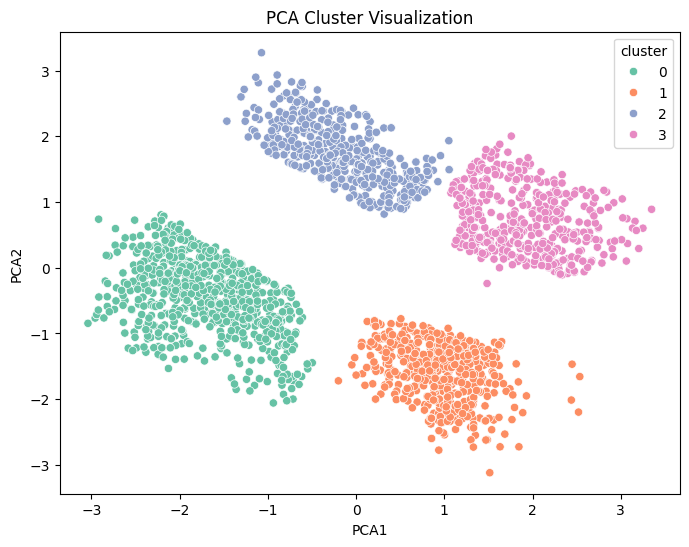

In [59]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('PCA Cluster Visualization')
plt.show()

Code chạy nhanh

Silhouette Score: 0.4031


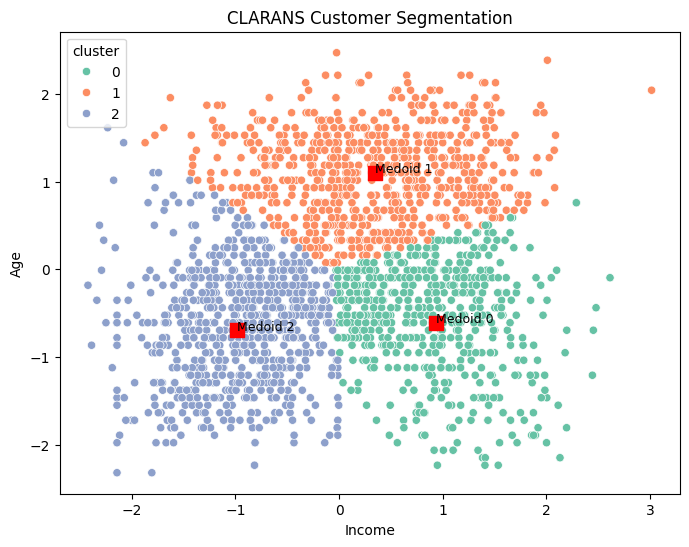

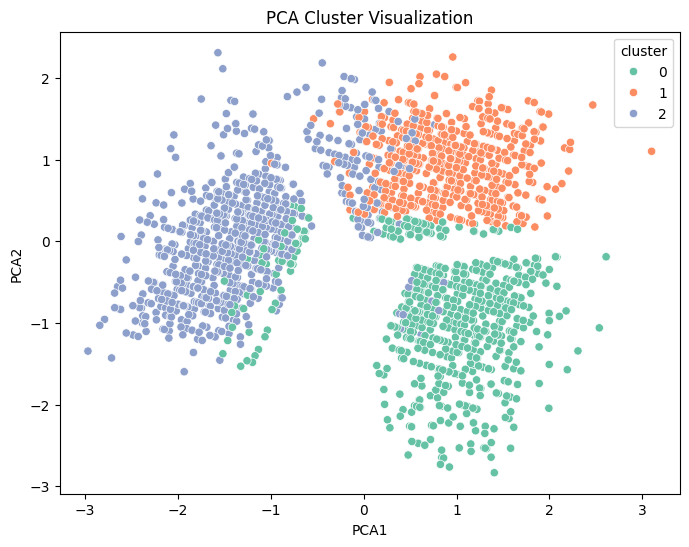

In [23]:
k = 3
n_local=5
max_nei=100
features = [
'Income',
'Age']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

clarans_fast_build(datafast,k,n_local,max_nei,'Income','Age')

pca=PCA(n_components=2)
pca.fit(datafast)
PCA_ds=pd.DataFrame(pca.transform(datafast),columns=(['col1','col2']))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('PCA Cluster Visualization')
plt.show()


Silhouette Score: 0.3635


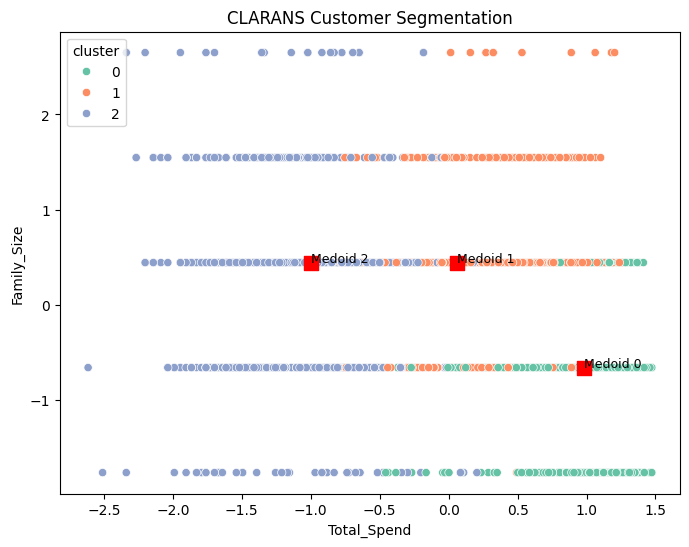

       col1      col2      col3  cluster
0  1.999764 -1.220482 -0.530495        0


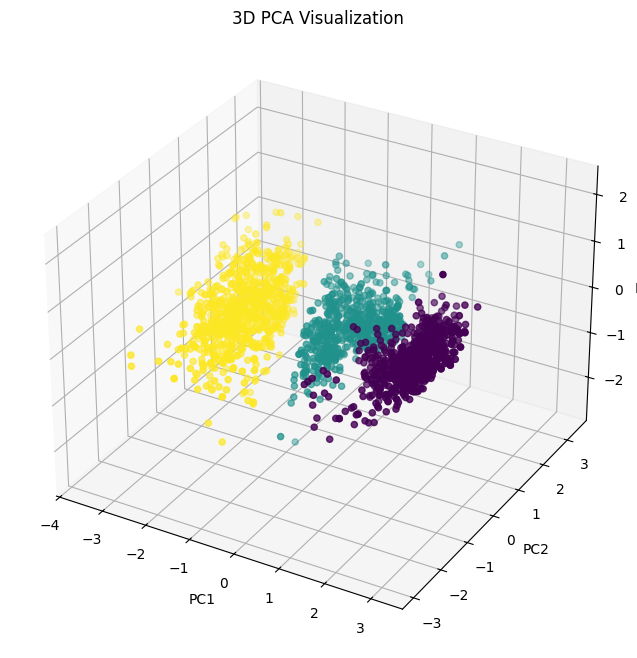

In [24]:
k = 3
n_local=5
max_nei=100
features = [
'Income',
'Family_Size',
'Total_Spend']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

clarans_fast_build(datafast,k,n_local,max_nei,'Total_Spend','Family_Size')

pca=PCA(n_components=3)
pca.fit(datafast)
PCA_ds=pd.DataFrame(pca.transform(datafast),columns=(['col1','col2','col3']))
PCA_ds['cluster']=datafast['cluster']
print(PCA_ds.head(1))

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xs=PCA_ds['col1'],ys=PCA_ds['col2'],zs=PCA_ds['col3'],c=PCA_ds['cluster'], marker="o" )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.set_title("3D PCA Visualization")
plt.show()


Silhouette Score: 0.3727


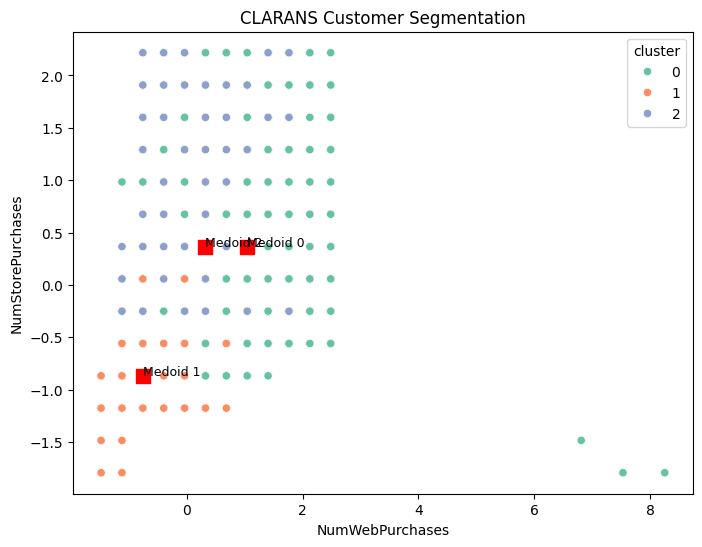

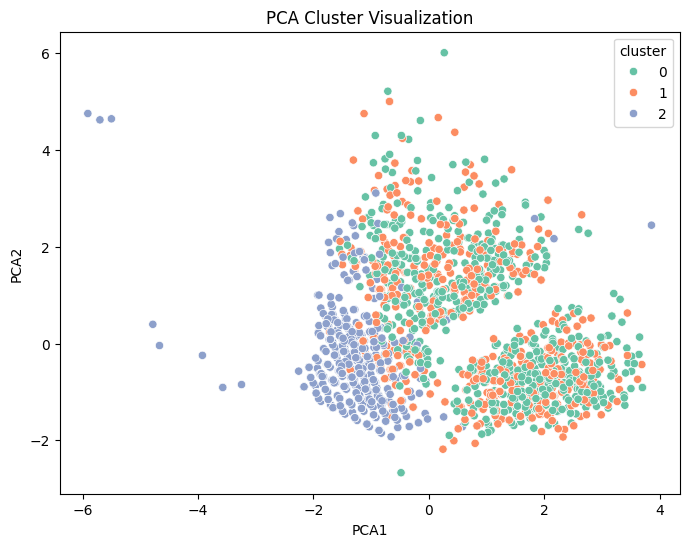

In [25]:
k = 3
n_local=5
max_nei=100
features = ['NumWebPurchases',
'NumStorePurchases',
'NumCatalogPurchases',
'NumWebVisitsMonth',
'NumDealsPurchases']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

clarans_fast_build(datafast,k,n_local,max_nei,'NumWebPurchases','NumStorePurchases')

pca=PCA(n_components=2)
pca.fit(datafast)
PCA_ds=pd.DataFrame(pca.transform(datafast),columns=(['col1','col2']))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('PCA Cluster Visualization')
plt.show()


Silhouette Score: 0.3570


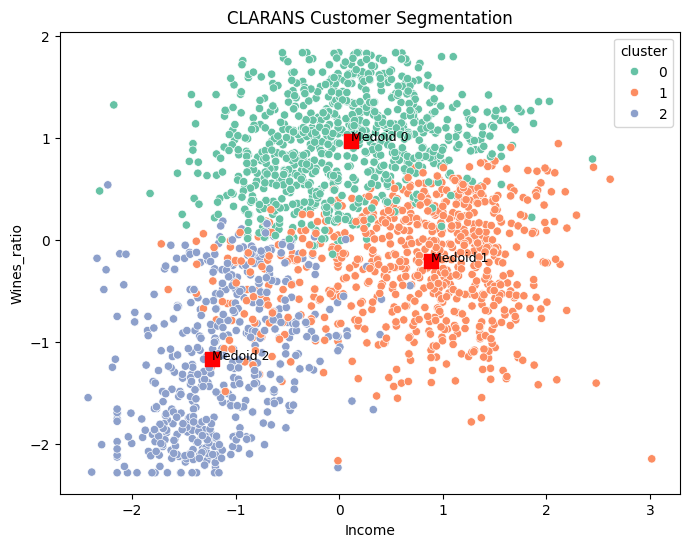

Silhouette Score: 0.3579


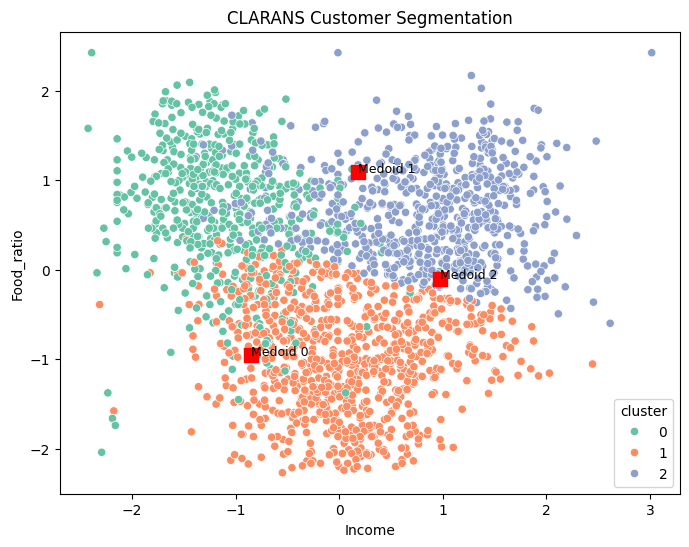

Silhouette Score: 0.3584


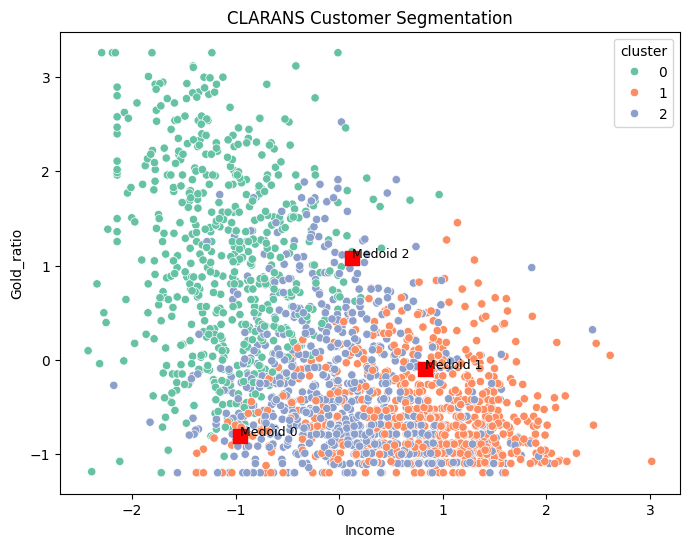

In [26]:
k = 3
n_local=5
max_nei=100
features = ['Income','Wines_ratio','Food_ratio','Gold_ratio']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

clarans_fast_build(datafast,k,n_local,max_nei,'Income','Wines_ratio')
clarans_fast_build(datafast,k,n_local,max_nei,'Income','Food_ratio')
clarans_fast_build(datafast,k,n_local,max_nei,'Income','Gold_ratio')


Silhouette Score: 0.3557


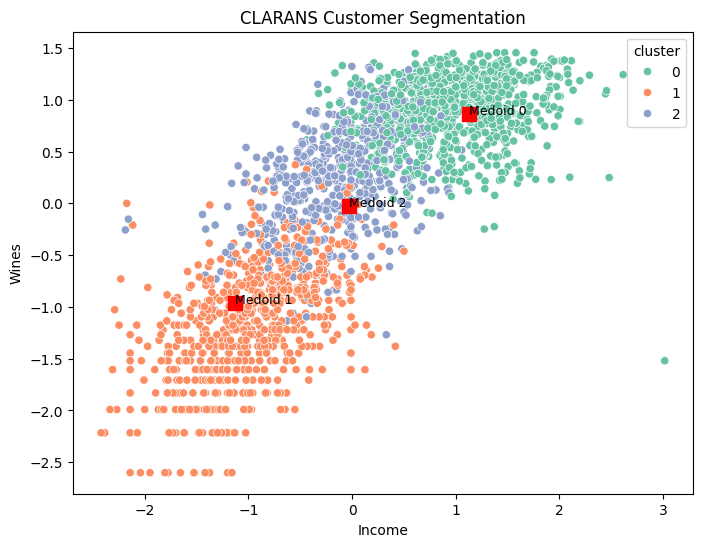

Silhouette Score: 0.3551


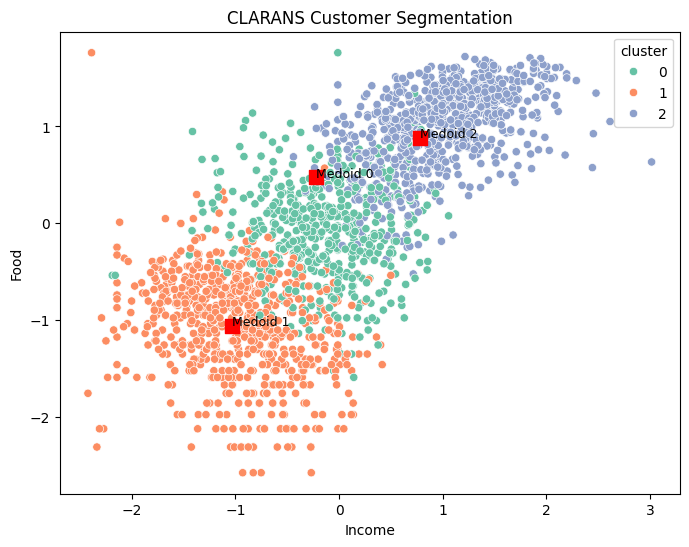

Silhouette Score: 0.3561


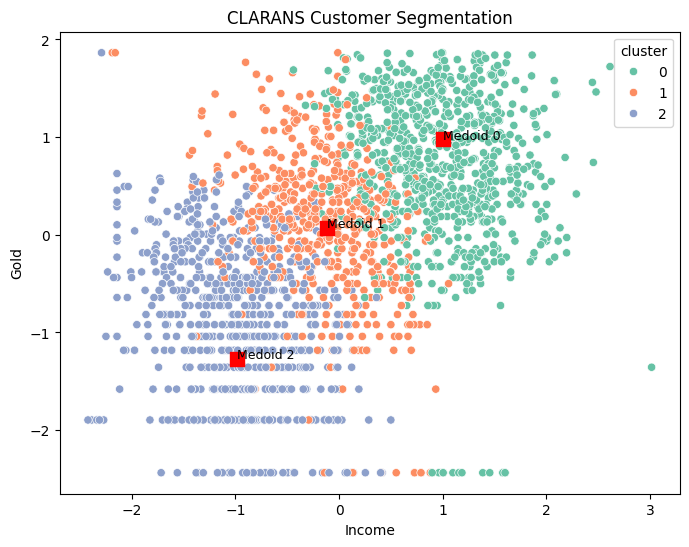

In [27]:
k = 3
n_local=5
max_nei=100
features = ['Income','Wines','Food','Gold']
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

clarans_fast_build(datafast,k,n_local,max_nei,'Income','Wines')
clarans_fast_build(datafast,k,n_local,max_nei,'Income','Food')
clarans_fast_build(datafast,k,n_local,max_nei,'Income','Gold')
